# Анализ корпуса открыток (постсоветский период)

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()

## 1. Загрузка данных

In [7]:
df = pd.read_csv('../data/[2025.12.01] Пишу тебе. Корпус - [2025.12.01] Пишу тебе. Корпус.csv')
df.head()

,Номер открытки,Лицевая сторона - ссылка,Оборотная сторона - ссылка,Язык текста открытки,Текст открытки,Перевод текста открытки (если на иностранном языке),Вид орфографии,"Дата написания текста (если автор указал явно, не штемпели)",Адрес отправителя,Имя отправителя,...,Населенный пункт (куда),Тег_1,Тег_2,Тег_3,Тег_4,Тег_5,Тег_6,Тег_7,Коллекция,Музейная коллекция
0,50,https://storage.yandexcloud.net/postcards-resi...,https://storage.yandexcloud.net/postcards-resi...,русский,"{Милый Жоржик! Простите, голубчик, за молчание...",NaN,"Дореволюционная (ъ,ѣ и т.д.)",[отсутствует],г. Одесса,[отсутствует],...,"Тифлисская губерния, Тифлисский уезд, г. Тифлис",Шлю привет,Житейское,Дурные вести,Учеба,"Простите, что долго не писал",NaN,NaN,[отсутствует],[отсутствует]
1,51,https://storage.yandexcloud.net/postcards-resi...,https://storage.yandexcloud.net/postcards-resi...,русский,Добрейший Паша! Будь добр вышли мне на консерв...,NaN,"Дореволюционная (ъ,ѣ и т.д.)",xx.xx.xxxx,Москва,М.Каневски,...,"Область Войска Донского, Ростовский уезд, г. Р...",Просьба,Рассказ об искусстве,Шлю привет,NaN,NaN,NaN,NaN,[отсутствует],[отсутствует]
2,52,https://storage.yandexcloud.net/postcards-resi...,https://storage.yandexcloud.net/postcards-resi...,русский,Милая моя Олечка! Открытку твою получила. Спас...,NaN,"Дореволюционная (ъ,ѣ и т.д.)",07.12.1910,Одесса,[отсутствует],...,"Тифлисская губерния, Тифлисский уезд, г. Тифлис",Новости,Житейское,Дурные вести,Письма от семьи,Письма от мамы,Шлю привет,NaN,[отсутствует],[отсутствует]
3,67,https://storage.yandexcloud.net/postcards-resi...,https://storage.yandexcloud.net/postcards-resi...,немецкий,Odessa. 30. 7. 01. Herzliche Grüße von [?M.Cho...,Сердечный привет от [?М. Холоденко],Латиница/дореволюционная,30.07.1901,Одесса,[?M.Cholodenko] [Перевод] [?М. Холоденко],...,"Саксония, г. Дрезден",Шлю привет,Иностранный язык,NaN,NaN,NaN,NaN,NaN,[отсутствует],[отсутствует]
4,68,https://storage.yandexcloud.net/postcards-resi...,https://storage.yandexcloud.net/postcards-resi...,иностранный язык,[отсутствует],NaN,Латиница,[отсутствует],[отсутствует],[отсутствует],...,[отсутствует],NaN,NaN,NaN,NaN,NaN,NaN,NaN,[отсутствует],[отсутствует]


## 2. Первичный анализ

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 61175 entries, 0 to 61174
Data columns (total 36 columns):
 #   Column                                                                                                                                                    Non-Null Count  Dtype 
---  ------                                                                                                                                                    --------------  ----- 
 0   Номер открытки                                                                                                                                            61175 non-null  int64 
 1   Лицевая сторона - ссылка                                                                                                                                  61175 non-null  object
 2   Оборотная сторона - ссылка                                                                                                                                6117

In [9]:
df.shape

(61175, 36)

## 3. Фильтрация данных

In [10]:
df_filtered = df.copy()
df_filtered = df_filtered[df_filtered['Период (дореволюционный, советский, постсоветский)'] == 'Постсоветские']
df_filtered = df_filtered[df_filtered['Язык текста открытки'] == 'русский']
df_filtered = df_filtered[df_filtered['Текст открытки'] != '[отсутствует]']

df_filtered.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2092 entries, 980 to 61101
Data columns (total 36 columns):
 #   Column                                                                                                                                                    Non-Null Count  Dtype 
---  ------                                                                                                                                                    --------------  ----- 
 0   Номер открытки                                                                                                                                            2092 non-null   int64 
 1   Лицевая сторона - ссылка                                                                                                                                  2092 non-null   object
 2   Оборотная сторона - ссылка                                                                                                                                2092 non

### 3.2 Работа с датами

Нормализация дат

In [11]:
df_filtered['Дата открытки (нормализованная)'] = pd.to_datetime(
    df_filtered['Дата открытки (нормализованная)'], 
    dayfirst=True
)

Проверка пропусков

In [12]:
df_filtered['Дата открытки (нормализованная)'].isna().sum()

159

### 3.3 Распределение по годам

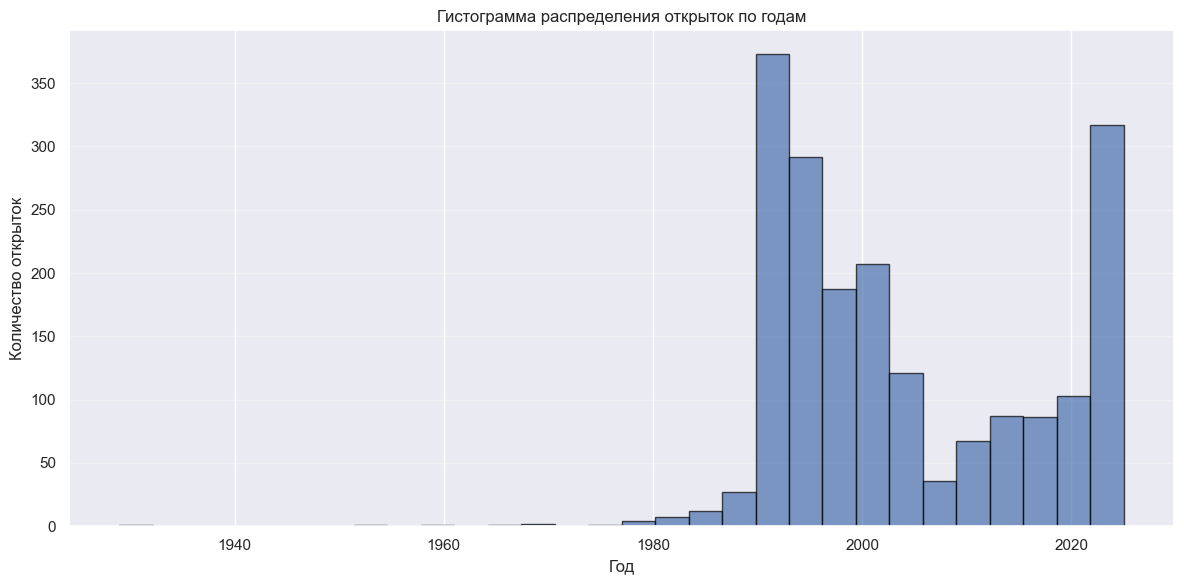

In [13]:
plt.figure(figsize=(12, 6))
plt.hist(df_filtered['Дата открытки (нормализованная)'].dt.year, bins=30, edgecolor='black', alpha=0.7)
plt.title('Гистограмма распределения открыток по годам')
plt.xlabel('Год')
plt.ylabel('Количество открыток')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### 3.4 Фильтрация по дате

Оставим только те открытки, которые были отправлены после распада СССР

In [14]:
df_final = df_filtered[
    (df_filtered['Дата открытки (нормализованная)'] > pd.Timestamp('1991-12-26')) |
    (df_filtered['Дата открытки (нормализованная)'].isna())
]

## 4. Итоговый датасет

In [15]:
print("Минимальная дата:", df_final['Дата открытки (нормализованная)'].min())
print("Максимальная дата:", df_final['Дата открытки (нормализованная)'].max())
print("Всего открыток:", len(df_final))

Минимальная дата: 1992-01-01 00:00:00
Максимальная дата: 2025-06-04 00:00:00
Всего открыток: 1888


In [17]:
df_final.to_csv('../data/postcard_filtred.csv', index=False, encoding='utf-8')